# Traitement du labo 2

Notebook de traitement pour l'actionneur a bobine mobile a partir des fichiers Tektronix dans `assets/`.

Le notebook couvre:
- EX1: estimation de `R` et `L` a partir des reponses indicielles
- EX2: bobine ouverte, extraction de `d`, `w0`, `Cv/J` et `Kr/J`
- EX3: bobine en court-circuit, extraction de `d'`, `w0'` et comparaison avec EX2
- Synthese: formules pour `Ku`, `J`, `Cv` et `Kr`


In [13]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pandas n'est pas installe dans l'environnement du notebook. Lance `uv sync` puis reessaie."
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ASSETS = Path("assets")
DAMAX_DEG = 17.1
DAMAX_RAD = np.deg2rad(DAMAX_DEG)
CURRENT_GAIN_A_PER_V = 1.0

FILES = {
    "ex1_moving": ASSETS / "T0000ALL.CSV",
    "ex1_blocked": ASSETS / "T0001ALL.CSV",
    "ex2_right_open": ASSETS / "T0002CH1.CSV",
    "ex2_left_open": ASSETS / "T0003CH1.CSV",
    "ex3_right_short": ASSETS / "T0004CH1.CSV",
    "ex3_left_short": ASSETS / "T0005CH1.CSV",
}


In [14]:
def load_tek_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=15)
    df = df.rename(columns=lambda c: c.strip().replace(" ", "_").replace("/", "_"))
    return df.apply(pd.to_numeric, errors="coerce")


def moving_average(y, window=25):
    y = np.asarray(y, dtype=float)
    if window <= 1:
        return y.copy()
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(y, kernel, mode="same")


def find_edges(signal, threshold_ratio=0.45):
    signal = np.asarray(signal, dtype=float)
    ds = np.diff(moving_average(signal, 31))
    peak = np.max(np.abs(ds))
    mask = np.abs(ds) > threshold_ratio * peak
    idx = np.flatnonzero(mask)
    if len(idx) == 0:
        raise ValueError("Impossible de detecter un front sur ce signal.")
    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    return [int(g[len(g) // 2]) for g in groups]


def plot_channels(df, title, columns):
    fig, ax = plt.subplots()
    t = df["TIME"].to_numpy()
    for column in columns:
        ax.plot(t, df[column], label=column)
    ax.set_title(title)
    ax.set_xlabel("Temps [s]")
    ax.legend()
    plt.show()


def nearest_crossing_time(t, y, level=0.0, start_index=0):
    t = np.asarray(t)
    y = np.asarray(y) - level
    for i in range(max(1, start_index), len(y)):
        if y[i - 1] == 0:
            return t[i - 1]
        if y[i - 1] * y[i] <= 0:
            x0, x1 = t[i - 1], t[i]
            y0, y1 = y[i - 1], y[i]
            if y1 == y0:
                return x0
            return x0 - y0 * (x1 - x0) / (y1 - y0)
    return np.nan


def absolute_peaks(y, start=0, stop=None, min_distance=300):
    y = np.asarray(y, dtype=float)
    if stop is None:
        stop = len(y)
    a = np.abs(y)
    peaks = []
    last = -10**9
    for i in range(max(1, start), min(stop - 1, len(a) - 1)):
        if a[i - 1] < a[i] >= a[i + 1] and i - last >= min_distance:
            peaks.append(i)
            last = i
    return np.array(peaks, dtype=int)


def summarize_table(rows):
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


## EX1 - Mesure des parametres electriques

`T0000ALL.CSV` correspond a l'essai avec mouvement et `T0001ALL.CSV` a l'essai avec l'actionneur maintenu.

L'objectif ici est de:
- visualiser la tension appliquee et la reponse de courant
- comparer l'effet du mouvement sur le courant
- obtenir une premiere estimation de `R` et `L` avec l'essai bloque


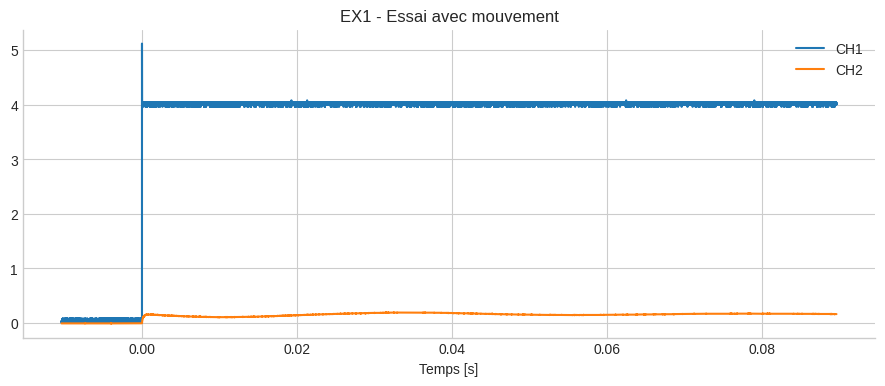

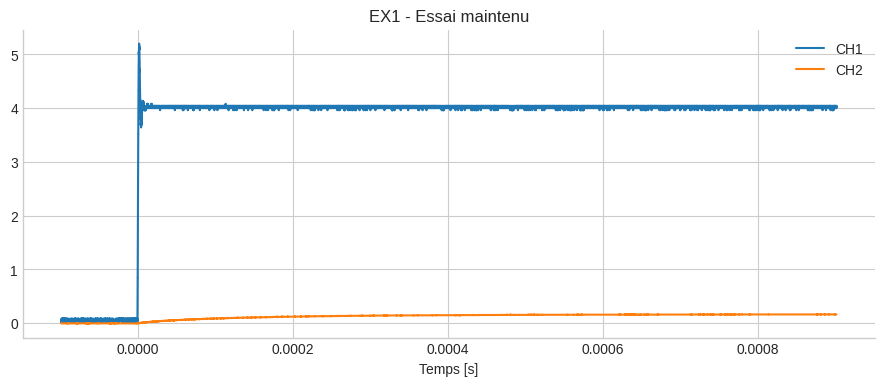

In [15]:
ex1_moving = load_tek_csv(FILES["ex1_moving"])
ex1_blocked = load_tek_csv(FILES["ex1_blocked"])

plot_channels(ex1_moving, "EX1 - Essai avec mouvement", ["CH1", "CH2"])
plot_channels(ex1_blocked, "EX1 - Essai maintenu", ["CH1", "CH2"])


In [16]:
def estimate_rl(df, voltage_col="CH1", current_col="CH2", current_gain=CURRENT_GAIN_A_PER_V):
    t = df["TIME"].to_numpy(dtype=float)
    u = df[voltage_col].to_numpy(dtype=float)
    i = df[current_col].to_numpy(dtype=float) * current_gain

    edges = find_edges(u)
    if len(edges) < 2:
        raise ValueError("Il faut au moins un front montant et un front descendant pour estimer R et L.")

    rising = edges[0]
    falling = next((idx for idx in edges[1:] if idx > rising), None)
    if falling is None:
        raise ValueError("Front descendant non detecte.")

    pre_slice = slice(max(0, rising - 1200), max(1, rising - 120))
    plateau_slice = slice(min(rising + 120, len(t) - 1), max(rising + 121, falling - 120))

    u0 = np.nanmean(u[pre_slice])
    u1 = np.nanmean(u[plateau_slice])
    i0 = np.nanmean(i[pre_slice])
    i1 = np.nanmean(i[plateau_slice])

    du = u1 - u0
    di = i1 - i0
    r_est = du / di

    fit_t = t[rising:falling] - t[rising]
    fit_i = i[rising:falling]
    z = i1 - fit_i
    valid = np.isfinite(z) & (z > 0) & (fit_t >= 0)
    valid &= fit_t <= max(fit_t) * 0.35

    tau = np.nan
    if np.count_nonzero(valid) >= 10:
        slope, intercept = np.polyfit(fit_t[valid], np.log(z[valid]), 1)
        tau = -1.0 / slope

    l_est = r_est * tau

    return {
        "edges": edges,
        "rising_time_s": t[rising],
        "falling_time_s": t[falling],
        "u0_V": u0,
        "u1_V": u1,
        "i0_A": i0,
        "i1_A": i1,
        "R_ohm": r_est,
        "tau_s": tau,
        "L_H": l_est,
    }


ex1_results = []
for label, df in [("Avec mouvement", ex1_moving), ("Maintenu", ex1_blocked)]:
    try:
        result = estimate_rl(df)
        result["essai"] = label
        ex1_results.append(result)
    except Exception as exc:
        ex1_results.append({"essai": label, "erreur": str(exc)})

summarize_table(ex1_results)


,edges,rising_time_s,falling_time_s,u0_V,u1_V,i0_A,i1_A,R_ohm,tau_s,L_H,essai,erreur
0,"[12981, 124991]",8.000000e-07,0.089609,0.038926,4.004677,-0.007387,0.156319,24.22479,0.079902,1.9356,Avec mouvement,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Maintenu,Il faut au moins un front montant et un front ...


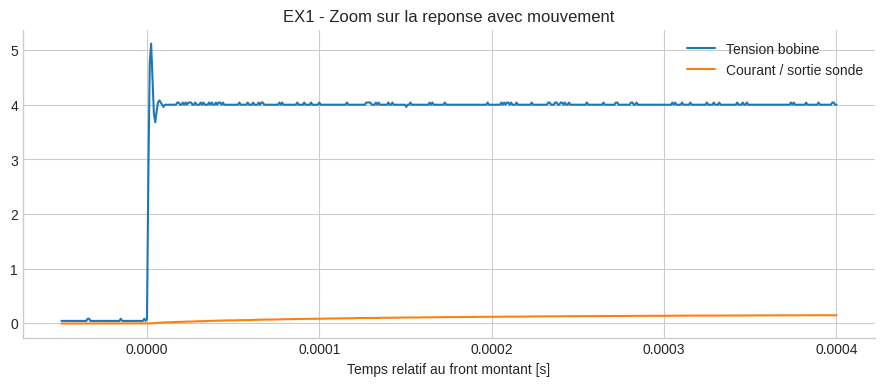

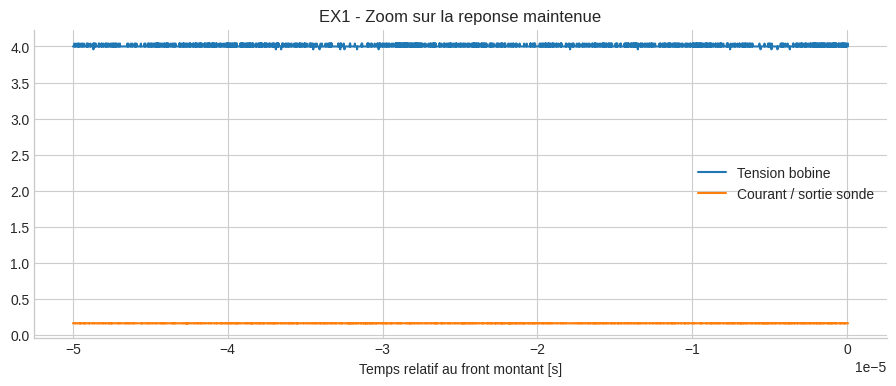

In [17]:
def zoom_first_step(df, title, voltage_col="CH1", current_col="CH2"):
    t = df["TIME"].to_numpy(dtype=float)
    u = df[voltage_col].to_numpy(dtype=float)
    i = df[current_col].to_numpy(dtype=float) * CURRENT_GAIN_A_PER_V
    rising = find_edges(u)[0]
    t0 = t[rising]
    mask = (t >= t0 - 5e-5) & (t <= t0 + 4e-4)

    fig, ax = plt.subplots()
    ax.plot(t[mask] - t0, u[mask], label="Tension bobine")
    ax.plot(t[mask] - t0, i[mask], label="Courant / sortie sonde")
    ax.set_title(title)
    ax.set_xlabel("Temps relatif au front montant [s]")
    ax.legend()
    plt.show()


zoom_first_step(ex1_moving, "EX1 - Zoom sur la reponse avec mouvement")
zoom_first_step(ex1_blocked, "EX1 - Zoom sur la reponse maintenue")


## EX2 - Bobine ouverte

On exploite `T0002CH1.CSV` et `T0003CH1.CSV` pour identifier la reponse oscillatoire amortie.

Le traitement ci-dessous:
- isole une fenetre d'analyse
- repere les pics de `|uim(t)|`
- estime la pseudo-periode et donc `w0`
- estime l'enveloppe exponentielle pour obtenir `d`
- calcule ensuite `Cv/J = 2d` et `Kr/J = d^2 + w0^2`

Si un resultat semble decalé, ajuste simplement les fenetres dans `OPEN_WINDOWS`.


In [18]:
OPEN_WINDOWS = {
    "Droite ouverte": (0.006, 0.085),
    "Gauche ouverte": (-0.022, 0.055),
}

open_files = {
    "Droite ouverte": FILES["ex2_right_open"],
    "Gauche ouverte": FILES["ex2_left_open"],
}


In [19]:
def analyze_damped_signal(df, label, t_min, t_max, signal_col="CH1", min_distance=500):
    t = df["TIME"].to_numpy(dtype=float)
    y = df[signal_col].to_numpy(dtype=float)
    y_smooth = moving_average(y, 21)

    mask = (t >= t_min) & (t <= t_max)
    tw = t[mask]
    yw = y_smooth[mask]
    if len(tw) < 10:
        raise ValueError(f"Fenetre trop petite pour {label}.")

    peaks_local = absolute_peaks(yw, start=5, stop=len(yw) - 5, min_distance=min_distance)
    if len(peaks_local) < 4:
        raise ValueError(f"Pas assez de pics detectes pour {label}.")

    peak_t = tw[peaks_local]
    peak_y = yw[peaks_local]
    peak_abs = np.abs(peak_y)

    keep = peak_abs > 0.08 * np.nanmax(peak_abs)
    peak_t = peak_t[keep]
    peak_y = peak_y[keep]
    peak_abs = peak_abs[keep]
    if len(peak_t) < 4:
        raise ValueError(f"Pas assez de pics utiles apres filtrage pour {label}.")

    half_period = float(np.nanmean(np.diff(peak_t[: min(len(peak_t), 8)])))
    full_period = 2.0 * half_period
    w0 = 2.0 * np.pi / full_period

    slope, intercept = np.polyfit(peak_t, np.log(peak_abs), 1)
    d = -slope

    first_peak_time = peak_t[0]
    release_time = first_peak_time - np.pi / (2.0 * w0)
    envelope_at_release = float(np.exp(intercept + slope * release_time))

    return {
        "label": label,
        "t": t,
        "y": y,
        "y_smooth": y_smooth,
        "window_mask": mask,
        "peak_t": peak_t,
        "peak_y": peak_y,
        "d": d,
        "w0": w0,
        "Cv_over_J": 2.0 * d,
        "Kr_over_J": d ** 2 + w0 ** 2,
        "release_time_s": release_time,
        "envelope_at_release": envelope_at_release,
    }


open_analysis = {}
for label, path in open_files.items():
    df = load_tek_csv(path)
    t_min, t_max = OPEN_WINDOWS[label]
    open_analysis[label] = analyze_damped_signal(df, label, t_min, t_max)

summarize_table([
    {
        "essai": label,
        "d_rad_s": result["d"],
        "w0_rad_s": result["w0"],
        "Cv_over_J_s-1": result["Cv_over_J"],
        "Kr_over_J_s-2": result["Kr_over_J"],
        "release_time_s": result["release_time_s"],
    }
    for label, result in open_analysis.items()
])


,essai,d_rad_s,w0_rad_s,Cv_over_J_s-1,Kr_over_J_s-2,release_time_s
0,Droite ouverte,4.196907,1896.835200,8.393814,3.598001e+06,0.005188
1,Gauche ouverte,7.467552,1942.955592,14.935104,3.775132e+06,-0.022783


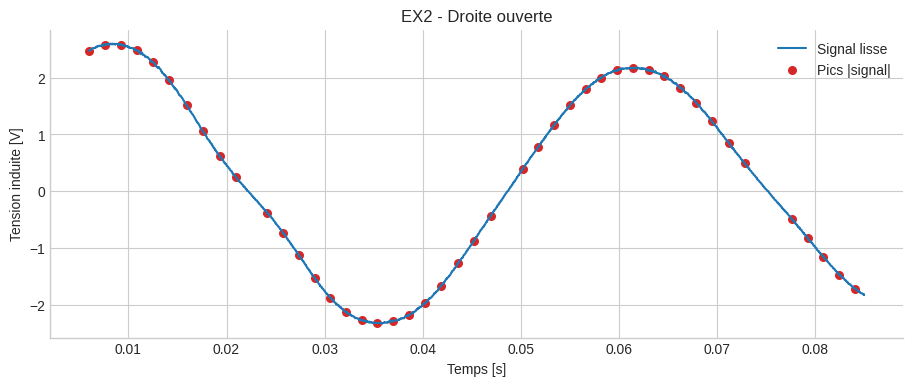

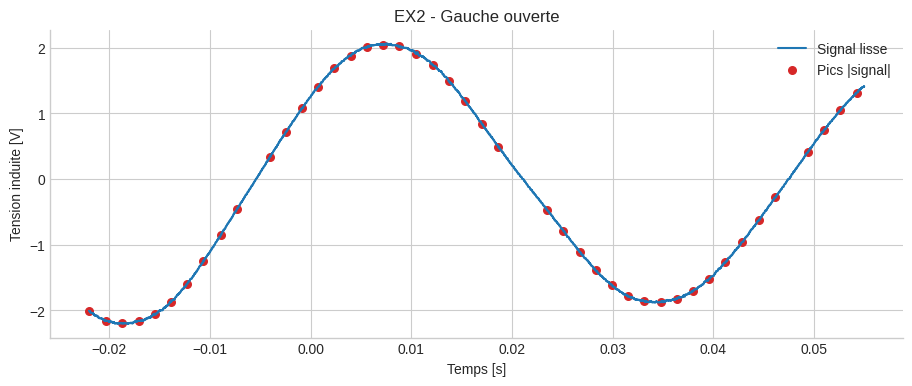

In [20]:
for label, result in open_analysis.items():
    mask = result["window_mask"]
    t = result["t"][mask]
    y = result["y_smooth"][mask]

    fig, ax = plt.subplots()
    ax.plot(t, y, label="Signal lisse")
    ax.scatter(result["peak_t"], result["peak_y"], color="tab:red", s=30, label="Pics |signal|")
    ax.set_title(f"EX2 - {label}")
    ax.set_xlabel("Temps [s]")
    ax.set_ylabel("Tension induite [V]")
    ax.legend()
    plt.show()


## EX3 - Bobine en court-circuit

On reapplique la meme methode sur `T0004CH1.CSV` et `T0005CH1.CSV`.

La grandeur mesuree est ici le courant dans la bobine. On obtient donc `d'` et `w0'`, puis le terme:

`(Cv + Ku*Kt/R) / J = 2d'`


In [21]:
SHORT_WINDOWS = {
    "Droite court-circuit": (0.006, 0.04),
    "Gauche court-circuit": (-0.02, 0.015),
}

short_files = {
    "Droite court-circuit": FILES["ex3_right_short"],
    "Gauche court-circuit": FILES["ex3_left_short"],
}

short_analysis = {}
for label, path in short_files.items():
    df = load_tek_csv(path)
    t_min, t_max = SHORT_WINDOWS[label]
    short_analysis[label] = analyze_damped_signal(df, label, t_min, t_max)

summarize_table([
    {
        "essai": label,
        "d_prime_rad_s": result["d"],
        "w0_prime_rad_s": result["w0"],
        "equivalent_damping_over_J_s-1": result["Cv_over_J"],
        "Kr_over_J_s-2": result["Kr_over_J"],
    }
    for label, result in short_analysis.items()
])


,essai,d_prime_rad_s,w0_prime_rad_s,equivalent_damping_over_J_s-1,Kr_over_J_s-2
0,Droite court-circuit,24.558681,3894.720278,49.117362,1.516945e+07
1,Gauche court-circuit,54.141249,3910.232677,108.282497,1.529285e+07


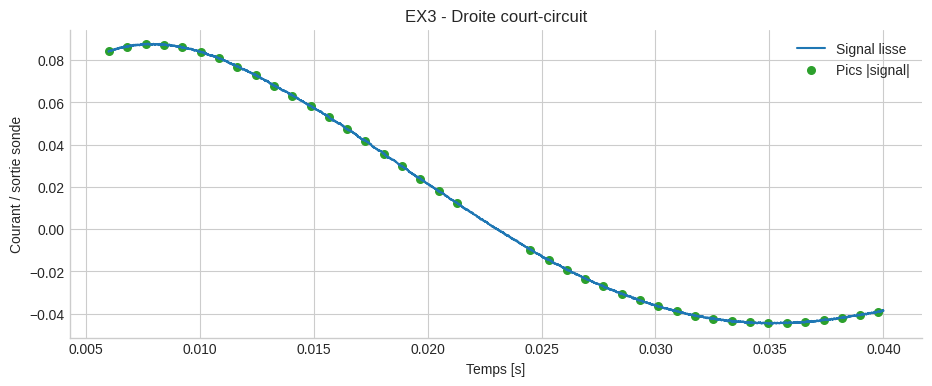

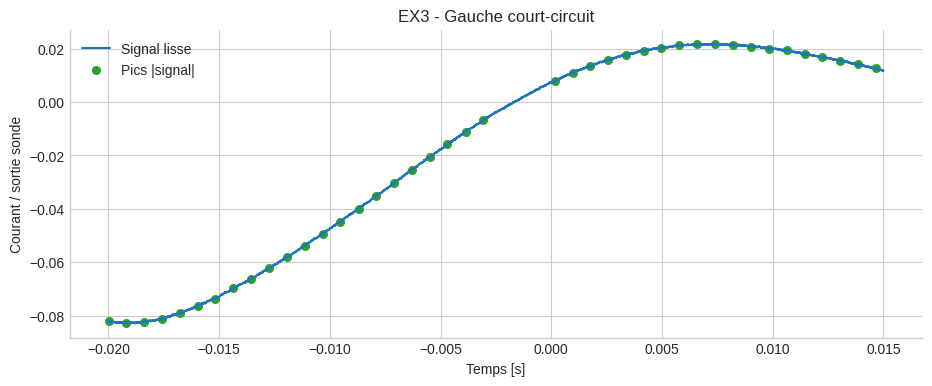

In [22]:
for label, result in short_analysis.items():
    mask = result["window_mask"]
    t = result["t"][mask]
    y = result["y_smooth"][mask]

    fig, ax = plt.subplots()
    ax.plot(t, y, label="Signal lisse")
    ax.scatter(result["peak_t"], result["peak_y"], color="tab:green", s=30, label="Pics |signal|")
    ax.set_title(f"EX3 - {label}")
    ax.set_xlabel("Temps [s]")
    ax.set_ylabel("Courant / sortie sonde")
    ax.legend()
    plt.show()


## Synthese des calculs

Les formules ci-dessous relient directement les mesures du notebook aux parametres demandes dans l'enonce.

Hypotheses utilisees ici:
- `Damax = 17.1 deg`
- `Ku = Kt` dans les unites SI
- l'amplitude d'enveloppe de l'essai bobine ouverte est une approximation de l'enveloppe theorique au relachement

Si besoin, tu peux remplacer les moyennes par les valeurs droite/gauche prises aux curseurs de l'oscilloscope.


In [23]:
open_summary = summarize_table([
    {
        "essai": label,
        "d": result["d"],
        "w0": result["w0"],
        "Cv_over_J": result["Cv_over_J"],
        "Kr_over_J": result["Kr_over_J"],
        "Uenv0": result["envelope_at_release"],
    }
    for label, result in open_analysis.items()
])
short_summary = summarize_table([
    {
        "essai": label,
        "d_prime": result["d"],
        "w0_prime": result["w0"],
        "equivalent_damping_over_J": result["Cv_over_J"],
    }
    for label, result in short_analysis.items()
])

open_summary, short_summary


(            essai         d           w0  Cv_over_J     Kr_over_J     Uenv0
 0  Droite ouverte  4.196907  1896.835200   8.393814  3.598001e+06  1.551891
 1  Gauche ouverte  7.467552  1942.955592  14.935104  3.775132e+06  1.604940,
                   essai    d_prime     w0_prime  equivalent_damping_over_J
 0  Droite court-circuit  24.558681  3894.720278                  49.117362
 1  Gauche court-circuit  54.141249  3910.232677                 108.282497)

In [24]:
R_USED = float(summarize_table(ex1_results).set_index("essai").loc["Maintenu", "R_ohm"])

open_mean = open_summary[["d", "w0", "Cv_over_J", "Kr_over_J", "Uenv0"]].mean(numeric_only=True)
short_mean = short_summary[["d_prime", "w0_prime", "equivalent_damping_over_J"]].mean(numeric_only=True)

Ku_est = open_mean["Uenv0"] * open_mean["w0"] / (DAMAX_RAD * open_mean["Kr_over_J"])
J_est = Ku_est ** 2 / (R_USED * (short_mean["equivalent_damping_over_J"] - open_mean["Cv_over_J"]))
Cv_est = J_est * open_mean["Cv_over_J"]
Kr_est = J_est * open_mean["Kr_over_J"]

summary = pd.DataFrame([
    {"parametre": "R", "valeur": R_USED, "unite": "ohm", "source": "EX1 maintenu"},
    {"parametre": "Ku = Kt", "valeur": Ku_est, "unite": "V/(rad/s) = Nm/A", "source": "EX2"},
    {"parametre": "J", "valeur": J_est, "unite": "kg m^2", "source": "EX2 + EX3"},
    {"parametre": "Cv", "valeur": Cv_est, "unite": "N m s", "source": "EX2 + EX3"},
    {"parametre": "Kr", "valeur": Kr_est, "unite": "N m / rad", "source": "EX2 + EX3"},
])
summary


,parametre,valeur,unite,source
0,R,NaN,ohm,EX1 maintenu
1,Ku = Kt,0.002754,V/(rad/s) = Nm/A,EX2
2,J,NaN,kg m^2,EX2 + EX3
3,Cv,NaN,N m s,EX2 + EX3
4,Kr,NaN,N m / rad,EX2 + EX3


## Remarques pratiques

- Si un calcul parait incoherent, commence par ajuster `OPEN_WINDOWS` et `SHORT_WINDOWS`.
- Pour EX1, `CURRENT_GAIN_A_PER_V` permet d'integrer le gain reel de la sonde de courant si tu veux convertir exactement en amperes.
- Les tableaux donnent une estimation automatique. Pour le rapport, tu peux tres bien reprendre les valeurs finales en mixant ce notebook avec les lectures curseur de l'oscilloscope.
